# Fase 2 - Comprension de los Datos
## Seccion 5: Analisis Geografico - Precios por Ciudad

**Notebook:** notebooks/04_EDA.ipynb
**Responsable:** Sofia | **Apoyo:** Steve
**Objetivo:** Analizar precios por ciudad, precio por m2, y cobertura Villavicencio con A7.

## Configuracion inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
RAW = os.path.join('..', 'data', 'raw')
PROC = os.path.join('..', 'data', 'processed')
OUT = 'outputs'
os.makedirs(OUT, exist_ok=True)
os.makedirs(PROC, exist_ok=True)
print(f'Raw: {os.path.abspath(RAW)} | Proc: {os.path.abspath(PROC)}')

Raw: c:\Users\AlexP\OneDrive\Escritorio\Accesibilidad_de_Vivienda_en_Colombia\data\raw | Proc: c:\Users\AlexP\OneDrive\Escritorio\Accesibilidad_de_Vivienda_en_Colombia\data\processed


---
## Celdas 46-50: Precio mediano por ciudad

### Cargar datasets con ciudad y precio

In [ ]:
datasets = {}
A1 = pd.read_csv(os.path.join(RAW, 'A1_colombia_housing_properties.csv'), encoding='utf-8-sig', low_memory=False)
A1['ciudad'] = A1['l3'].str.strip().str.title()
A1['fuente'] = 'A1'
datasets['A1'] = A1
A2 = pd.read_csv(os.path.join(RAW, 'A2_fincaraiz_colombia.csv'), encoding='utf-8-sig', low_memory=False)
A2['ciudad'] = A2['Ciudad'].str.strip().str.title()
A2['fuente'] = 'A2'
datasets['A2'] = A2
A5 = pd.read_csv(os.path.join(RAW, 'A5_medellin_properties_2023.csv'), encoding='utf-8-sig', low_memory=False)
A5['ciudad'] = 'Medellin'
A5['fuente'] = 'A5'
datasets['A5'] = A5
A7 = pd.read_csv(os.path.join(RAW, 'A7_fincaraiz_villavicencio_scraping.csv'), encoding='utf-8-sig', low_memory=False)
A7['ciudad'] = 'Villavicencio'
A7['fuente'] = 'A7'
datasets['A7'] = A7
print('Datasets cargados:')
for fid, df in datasets.items():
    print(f'  {fid}: {df.shape[0]:>8,} filas')

Datasets cargados:
  A1:  997,623 filas
  A2:  142,833 filas
  A5:    9,999 filas
  A7:    1,048 filas


### Mapear columna precio por dataset

In [ ]:
PRICE_MAP = {'A1': 'price', 'A2': 'Precio', 'A5': 'price', 'A7': 'precio_cop'}
price_data = []
for fid, df in datasets.items():
    pcol = PRICE_MAP[fid]
    pvals = df[pcol].dropna()
    pvals = pvals[pvals > 0]
    temp = df.loc[pvals.index, ['ciudad', 'fuente']].copy()
    temp['precio'] = pvals
    price_data.append(temp)
df_prices = pd.concat(price_data, ignore_index=True)
print(f'Registros con precio valido: {len(df_prices):,}')
print(f'Ciudades unicas: {df_prices["ciudad"].nunique()}')

Registros con precio valido: 1,151,503
Ciudades unicas: 1030


### Top 15 ciudades - precio mediano

In [ ]:
city_volume = df_prices.groupby('ciudad').size().sort_values(ascending=False).head(15).index
city_stats = df_prices[df_prices['ciudad'].isin(city_volume)].groupby('ciudad')['precio'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count'])
city_stats.columns = ['precio_mediano', 'Q1', 'Q3', 'N_registros']
city_stats = city_stats.sort_values('precio_mediano', ascending=False)
city_stats['precio_mediano'] = city_stats['precio_mediano'].map(lambda x: f'${x:,.0f}')
city_stats['Q1'] = city_stats['Q1'].map(lambda x: f'${x:,.0f}')
city_stats['Q3'] = city_stats['Q3'].map(lambda x: f'${x:,.0f}')
display(city_stats)

,precio_mediano,Q1,Q3,N_registros
ciudad,,,,
Bogotá,"$540,000,000","$310,000,000","$930,000,000",50948
Chía,"$485,000,000","$245,000,000","$970,000,000",13981
Envigado,"$354,500,000","$2,500,000","$690,000,000",27922
Jamundí,"$315,000,000","$140,000,000","$530,000,000",11212
Pereira,"$250,000,000","$6,280,000","$529,857,500",24202
Sabaneta,"$240,000,000","$1,500,000","$380,000,000",12877
Bogotá D.C,"$230,000,000","$2,859,699","$630,000,000",170205
Desconocido,"$220,000,000","$17,820,000","$450,000,000",62703
Cali,"$210,000,000","$2,500,000","$450,000,000",108639


### Barras - precio mediano por ciudad

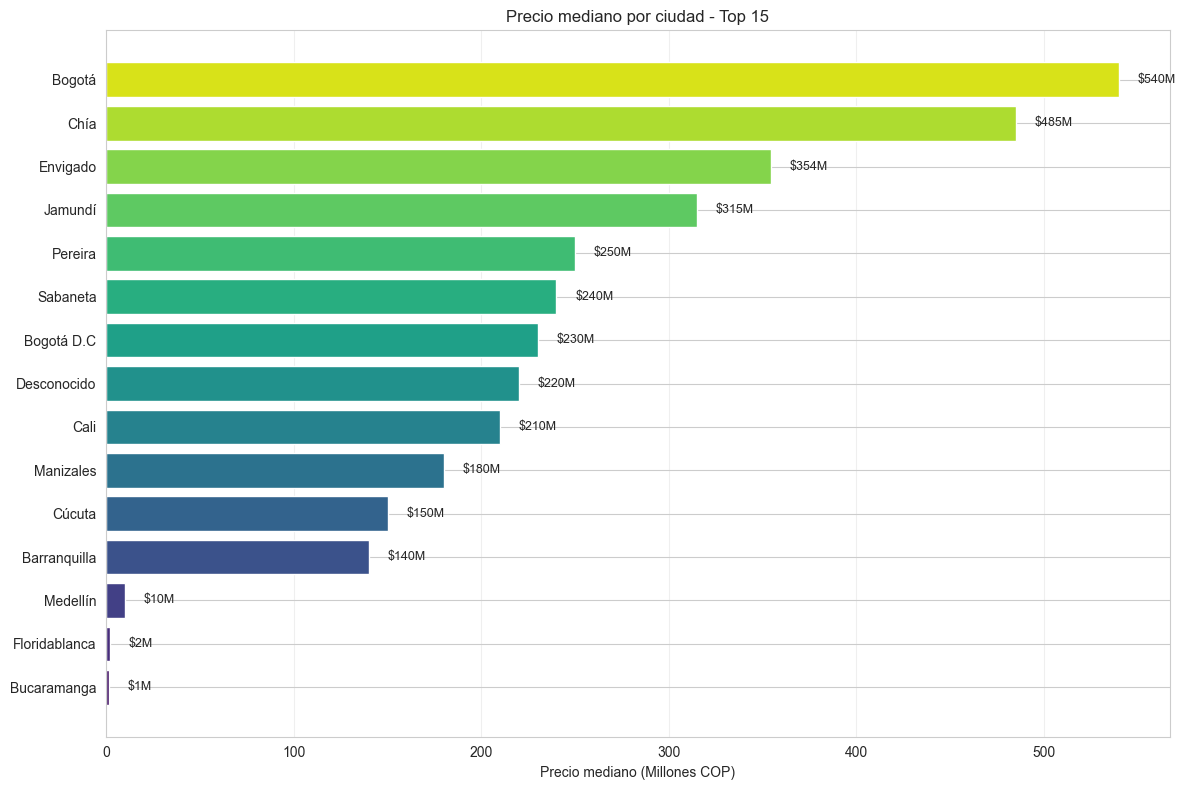

In [ ]:
city_stats_num = df_prices[df_prices['ciudad'].isin(city_volume)].groupby('ciudad')['precio'].median().sort_values()
plt.figure(figsize=(12, 8))
colors = sns.color_palette('viridis', len(city_stats_num))
bars = plt.barh(city_stats_num.index, city_stats_num.values / 1e6, color=colors, edgecolor='white')
for bar, val in zip(bars, city_stats_num.values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'${val/1e6:.0f}M', va='center', fontsize=9)
plt.xlabel('Precio mediano (Millones COP)')
plt.title('Precio mediano por ciudad - Top 15')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'precio_mediano_ciudad.png'), dpi=150, bbox_inches='tight')
plt.show()

### Segmentacion de ciudades

In [ ]:
city_medians = df_prices.groupby('ciudad')['precio'].median()
q33, q66 = city_medians.quantile([0.33, 0.66])
print(f'Umbral baja-media:  ${q33/1e6:,.0f}M')
print(f'Umbral media-alta:  ${q66/1e6:,.0f}M')
print('\n--- BAJO ---')
for c, m in city_medians[city_medians < q33].sort_values().items():
    n = len(df_prices[df_prices['ciudad'] == c])
    print(f'  {c:25s} ${m/1e6:>8.1f}M  ({n:,})')
print('\n--- MEDIO ---')
for c, m in city_medians[(city_medians >= q33) & (city_medians <= q66)].sort_values().items():
    n = len(df_prices[df_prices['ciudad'] == c])
    print(f'  {c:25s} ${m/1e6:>8.1f}M  ({n:,})')
print('\n--- ALTO ---')
for c, m in city_medians[city_medians > q66].sort_values().items():
    n = len(df_prices[df_prices['ciudad'] == c])
    print(f'  {c:25s} ${m/1e6:>8.1f}M  ({n:,})')

Umbral baja-media:  $250M
Umbral media-alta:  $465M

--- BAJO ---
  Santiago                  $     0.5M  (1)
  Puerto Rondón             $     0.8M  (1)
  San Juan Nepomuceno       $     0.9M  (1)
  Albania                   $     1.1M  (29)
  Sipí                      $     1.2M  (2)
  San Francisco             $     1.2M  (386)
  El Encanto                $     1.3M  (5)
  Bucaramanga               $     1.3M  (49,750)
  Yaguará                   $     1.4M  (1)
  Floridablanca             $     1.8M  (15,126)
  Prado                     $     1.9M  (68)
  Ragonvalia                $     2.0M  (9)
  Santander                 $     3.0M  (3)
  Providencia               $     3.6M  (24)
  Piedecuesta - Bucaramanga $     5.0M  (1)
  Barrancabermeja           $     5.0M  (2,003)
  Medellín                  $     9.9M  (275,864)
  Sabanagrande              $    10.0M  (47)
  Cabrera                   $    10.5M  (114)
  Caparrapi                 $    15.0M  (1)
  Leticia                 

---
## Celdas 51-55: Precio por m2 por ciudad

### Calcular precio/m2

In [ ]:
AREA_MAP = {'A1': 'area', 'A2': 'Area Construida', 'A5': 'area', 'A7': 'area_m2'}
price_m2_data = []
for fid, df in datasets.items():
    pcol = PRICE_MAP[fid]
    acol = AREA_MAP[fid]
    if acol not in df.columns:
        continue
    temp = df[[pcol, acol, 'ciudad', 'fuente']].dropna()
    temp = temp[(temp[pcol] > 0) & (temp[acol] > 0)]
    temp['precio_m2'] = temp[pcol] / temp[acol]
    price_m2_data.append(temp[['ciudad', 'fuente', 'precio_m2']])
df_m2 = pd.concat(price_m2_data, ignore_index=True)
print(f'Registros con precio/m2: {len(df_m2):,}')

Registros con precio/m2: 153,866


### Filtrar outliers precio/m2

In [ ]:
LIM_BAJO = 500_000; LIM_ALTO = 20_000_000
print(f'Antes: {len(df_m2):,}')
n_bajos = (df_m2['precio_m2'] < LIM_BAJO).sum()
n_altos = (df_m2['precio_m2'] > LIM_ALTO).sum()
print(f'  <$500K: {n_bajos} ({n_bajos/len(df_m2)*100:.1f}%)')
print(f'  >$20M:  {n_altos} ({n_altos/len(df_m2)*100:.1f}%)')
df_m2_clean = df_m2[(df_m2['precio_m2'] >= LIM_BAJO) & (df_m2['precio_m2'] <= LIM_ALTO)].copy()
print(f'Despues: {len(df_m2_clean):,} ({len(df_m2_clean)/len(df_m2)*100:.1f}%)')

Antes: 153,866
  <$500K: 512 (0.3%)
  >$20M:  254 (0.2%)
Despues: 153,100 (99.5%)


### Precio/m2 mediano por ciudad

In [ ]:
m2_by_city = df_m2_clean.groupby('ciudad')['precio_m2'].agg(['median','mean','count'])
m2_by_city.columns = ['m2_mediano','m2_medio','N']
m2_by_city = m2_by_city[m2_by_city['N'] >= 30].sort_values('m2_mediano', ascending=False)
tab = m2_by_city.copy()
tab['m2_mediano'] = tab['m2_mediano'].map(lambda x: f'${x:,.0f}')
tab['m2_medio'] = tab['m2_medio'].map(lambda x: f'${x:,.0f}')
display(tab.head(15))

,m2_mediano,m2_medio,N
ciudad,,,
El Retiro,"$7,463,415","$7,356,103",619
Medellín - Envigado,"$7,105,460","$7,289,655",132
Envigado,"$6,762,649","$6,835,189",3756
Envigado - Medellín,"$6,645,436","$6,942,817",130
La Calera - Bogotá,"$6,333,333","$5,943,737",47
Rionegro,"$5,982,143","$6,277,624",1703
Sabaneta,"$5,970,149","$5,915,508",2061
Cajicá - Chía,"$5,875,000","$5,962,600",37
La Estrella - Itaguí,"$5,684,932","$5,549,112",143


### Grafico precio/m2 por ciudad

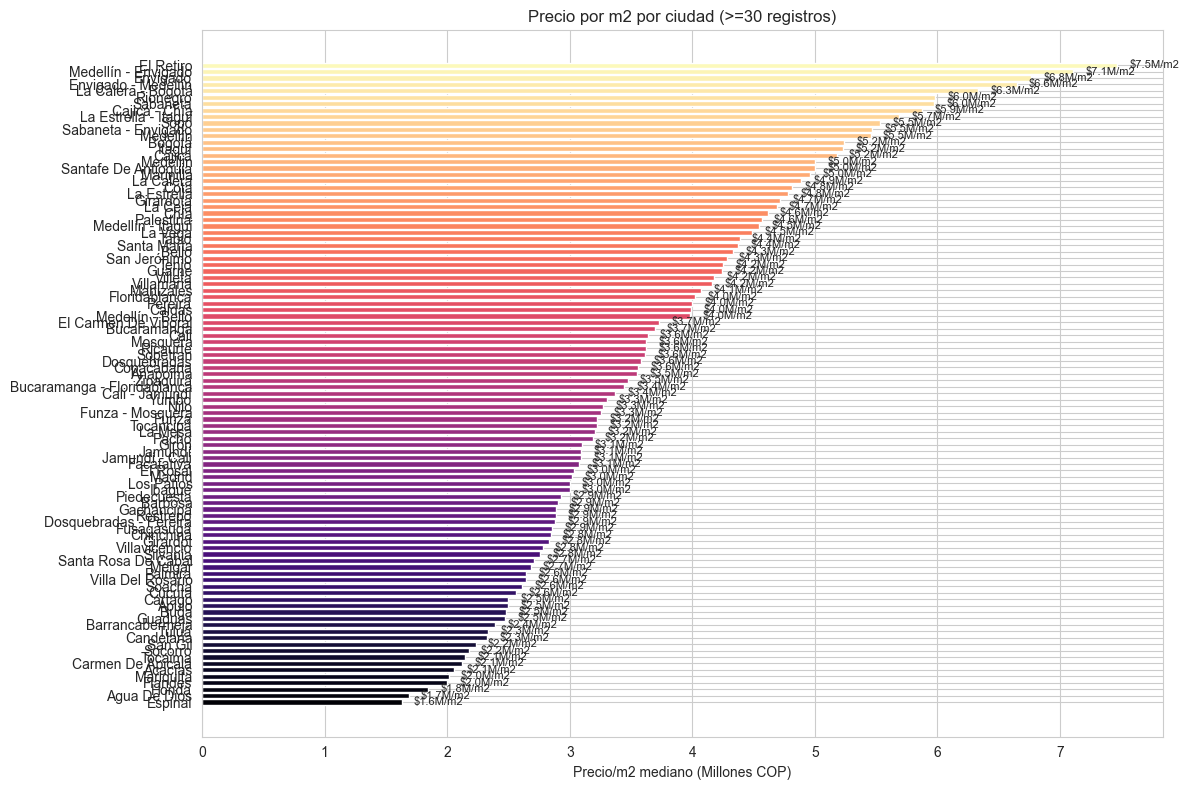

In [ ]:
m2_chart = df_m2_clean.groupby('ciudad')['precio_m2'].median().sort_values()
m2_chart = m2_chart[m2_chart.index.isin(m2_by_city.index)]
plt.figure(figsize=(12, 8))
colors = sns.color_palette('magma', len(m2_chart))
bars = plt.barh(m2_chart.index, m2_chart.values / 1e6, color=colors, edgecolor='white')
for bar, val in zip(bars, m2_chart.values):
    plt.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'${val/1e6:.1f}M/m2', va='center', fontsize=8)
plt.xlabel('Precio/m2 mediano (Millones COP)')
plt.title('Precio por m2 por ciudad (>=30 registros)')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'precio_m2_ciudad.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5-bis: Refuerzo Villavicencio (A7)
## Celdas 56-58: Explorar A7

### Estructura A7

In [ ]:
print(f'Dimensiones: {A7.shape[0]:,} x {A7.shape[1]}')
print('Columnas:')
for i, col in enumerate(A7.columns, 1):
    print(f'  {i:2d}. {col:25s}  dtype={A7[col].dtype}')
print(f'\nMemoria: {A7.memory_usage(deep=True).sum()/1e6:.2f} MB')

Dimensiones: 1,048 x 25
Columnas:
   1. id_anuncio                 dtype=int64
   2. uuid                       dtype=object
   3. precio_cop                 dtype=int64
   4. admin_cop                  dtype=float64
   5. admin_incluida             dtype=bool
   6. tipo_inmueble              dtype=object
   7. tipo_operacion             dtype=object
   8. area_m2                    dtype=float64
   9. area_construida_m2         dtype=float64
  10. habitaciones               dtype=int64
  11. banos                      dtype=int64
  12. parqueaderos               dtype=int64
  13. estrato                    dtype=int64
  14. piso                       dtype=int64
  15. antiguedad                 dtype=object
  16. estado                     dtype=object
  17. es_nuevo                   dtype=bool
  18. barrio                     dtype=object
  19. ciudad                     dtype=object
  20. departamento               dtype=object
  21. pais                       dtype=object
  22. ti

### Periodo A7

In [ ]:
print(f'Registros: {A7.shape[0]:,}')
print(f'Precio valido: {A7["precio_cop"].notna().sum():,}')
print(f'Area valida: {A7["area_m2"].notna().sum():,}')
date_col = None
for c in ['fecha_publicacion', 'created_on']:
    if c in A7.columns:
        date_col = c
        break
if date_col:
    A7[date_col] = pd.to_datetime(A7[date_col], errors='coerce')
    print(f'Periodo: {A7[date_col].min().date()} a {A7[date_col].max().date()}')

Registros: 1,048
Precio valido: 1,048
Area valida: 1,048


### Cobertura A1 vs A7

In [ ]:
vill_a1 = A1[A1['ciudad'] == 'Villavicencio']
vill_a7 = A7.copy()
vill_a7['ciudad'] = 'Villavicencio'
print('--- COBERTURA VILLAVICENCIO ---')
print(f"{'':20s} {'A1':>15s} {'A7':>15s}")
print(f"{'Registros':20s} {len(vill_a1):>15,} {len(vill_a7):>15,}")
print(f"{'Con precio':20s} {vill_a1['price'].notna().sum():>15,} {vill_a7['precio_cop'].notna().sum():>15,}")
print(f"{'Con area':20s} {'N/A':>15s} {vill_a7['area_m2'].notna().sum():>15,}")
print(f'\nRelacion A7/A1: {len(vill_a7)/max(len(vill_a1),1):.1f}x')

--- COBERTURA VILLAVICENCIO ---
                                  A1              A7
Registros                      5,372           1,048
Con precio                     5,372           1,048


KeyError: 'area'

---
## Celdas 59-61: Integracion con fuentes oficiales

### Cargar IPVN DANE

In [ ]:
ipvn_path = os.path.join(RAW, 'B1_indices_precios_vivienda.csv')
if os.path.exists(ipvn_path):
    B1 = pd.read_csv(ipvn_path, encoding='utf-8-sig')
    print(f'IPVN: {B1.shape[0]:,} filas x {B1.shape[1]} cols')
    display(B1.head(3))
else:
    B1 = None
    print('IPVN no encontrado')

### IPVN trimestral a anual

In [ ]:
if B1 is not None:
    ycol = None
    for c in B1.columns:
        if c.lower() in ['ano', 'a%co', 'year', 'annio']:
            ycol = c
            break
    if ycol:
        anual = B1.groupby(ycol).mean(numeric_only=True).reset_index()
        print('IPVN anual:')
        display(anual.head(10))
    else:
        print('Sin columna de year')

### Relacion A7 vs IPVN

In [ ]:
if B1 is not None and 'precio_cop' in A7.columns:
    p = A7['precio_cop'].dropna()
    p = p[p > 0]
    print(f'Precio mediano A7: ${p.median():,.0f}')
    print(f'Rango A7: ${p.min():,.0f} - ${p.max():,.0f}')

---
## Celdas 62-64: Analisis Villavicencio

### Estadisticas consolidado A1+A7

In [ ]:
v1 = vill_a1['price'].dropna(); v1 = v1[v1 > 0]
v7 = vill_a7['precio_cop'].dropna(); v7 = v7[v7 > 0]
print('--- VILLAVICENCIO ---')
print(f"{'':25s} {'A1':>18s} {'A7':>18s} {'Consol':>18s}")
print(f"{'N':25s} {len(v1):>18,} {len(v7):>18,} {len(v1)+len(v7):>18,}")
print(f"{'Min':25s} ${v1.min():>14,.0f} ${v7.min():>14,.0f} ${min(v1.min(),v7.min()):>14,.0f}")
print(f"{'Mediana':25s} ${v1.median():>14,.0f} ${v7.median():>14,.0f} ${pd.concat([v1,v7]).median():>14,.0f}")
print(f"{'Media':25s} ${v1.mean():>14,.0f} ${v7.mean():>14,.0f} ${pd.concat([v1,v7]).mean():>14,.0f}")
print(f"{'Max':25s} ${v1.max():>14,.0f} ${v7.max():>14,.0f} ${max(v1.max(),v7.max()):>14,.0f}")

### Comparar con ciudades similares

In [ ]:
similes = ['Ibague', 'Cucuta', 'Neiva', 'Pereira', 'Armenia', 'Manizales']
found = [c for c in similes if c in city_medians.index]
print('--- COMPARACION ---')
print(f"{'Ciudad':20s} {'Precio mediano':>20s} {'N':>10s}")
print(f"{'Villavicencio':20s} ${pd.concat([v1,v7]).median():>14,.0f} {len(v1)+len(v7):>10,}")
for c in found:
    pm = df_prices[df_prices['ciudad']==c]['precio'].median()
    n = len(df_prices[df_prices['ciudad']==c])
    print(f'{c:20s} ${pm:>14,.0f} {n:>10,}')

### Tipos de propiedad en Villavicencio

In [ ]:
tc = {'A7': 'tipo_inmueble', 'A1': 'property_type'}
for ds, col in tc.items():
    if col in eval(ds).columns:
        print(f'{ds}: {eval(ds)[col].value_counts().head(8).to_string()}')

### Calidad datos A7

In [ ]:
pct_n = (A7.isnull().sum()/len(A7)*100).sort_values(ascending=False)
nc = pct_n[pct_n > 0]
print(f'Cols con nulos: {len(nc)}/{len(A7.columns)}')
for col, pct in nc.items():
    print(f'  {col:25s} {pct:5.1f}%')
dups = A7.duplicated().sum()
print(f'Duplicados: {dups} ({dups/len(A7)*100:.1f}%)')

### Villavicencio en contexto nacional

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ctx = ['Bogota','Medellin','Cali','Barranquilla','Cartagena','Bucaramanga','Ibague','Cucuta','Pereira','Villavicencio']
f = [c for c in ctx if c in city_medians.index]
cm = city_medians[city_medians.index.isin(f)].sort_values()
clr = ['crimson' if c=='Villavicencio' else 'steelblue' for c in cm.index]
axes[0].barh(cm.index, cm.values/1e6, color=clr, edgecolor='white')
axes[0].set_xlabel('Precio mediano (Millones COP)')
axes[0].set_title('Villavicencio en contexto - Precio')
m2c = df_m2_clean[df_m2_clean['ciudad'].isin(f)].groupby('ciudad')['precio_m2'].median().sort_values()
clr2 = ['crimson' if c=='Villavicencio' else 'steelblue' for c in m2c.index]
axes[1].barh(m2c.index, m2c.values/1e6, color=clr2, edgecolor='white')
axes[1].set_xlabel('Precio/m2 mediano (Millones COP)')
axes[1].set_title('Villavicencio en contexto - Precio/m2')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'villavicencio_contexto_nacional.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Celdas 65-67: Documentacion estrategia A7

### Documentar A7

In [ ]:
print('--- DOCUMENTACION A7 ---')
print('Origen: Scraping FincaRaiz.com')
print(f'Registros: {len(A7):,}')
print('Razon: A1 tiene baja cobertura de Villavicencio')
print(f'  A1: {len(vill_a1):,} vs A7: {len(vill_a7):,}')
print('Limitaciones: solo FincaRaiz, periodo limitado, posibles duplicados con A2')

### Guardar consolidado Villavicencio

In [ ]:
A7_out = A7.rename(columns={'precio_cop':'price','area_m2':'area','habitaciones':'rooms','banos':'bathrooms','estrato':'estrato','parqueaderos':'parking'})
A7_out['fuente'] = 'A7'
A7_out['ciudad'] = 'Villavicencio'
vill_a1_out = vill_a1.copy()
vill_a1_out['fuente'] = 'A1'
if 'area' not in vill_a1_out.columns:
    vill_a1_out['area'] = None
cols = ['price','area','fuente','ciudad','rooms','bathrooms','estrato','parking']
for c in cols:
    if c not in vill_a1_out.columns: vill_a1_out[c] = None
    if c not in A7_out.columns: A7_out[c] = None
v_cons = pd.concat([vill_a1_out[cols], A7_out[cols]], ignore_index=True)
out_path = os.path.join(PROC, 'villavicencio_consolidado.csv')
v_cons.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Guardado: {out_path} ({len(v_cons):,} registros)')


---
## Resumen

- Precio mediano por ciudad (top 15).
- Segmentacion alta/media/baja.
- Precio/m2 por ciudad (outliers <$500K o >$20M filtrados).
- A7 explorado: estructura, periodo, calidad.
- A1 vs A7 cobertura comparada.
- IPVN DANE cargado como referencia.
- Consolidado guardado en data/processed/villavicencio_consolidado.csv.